In [1]:
# import and formatting statements

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import re

plt.rcParams['pdf.fonttype'] = 42
sns.set(style="whitegrid", context="talk")

file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name="Fig_4A+B_Extended_4E+F", index_col = 0)  
df.index = df.index.str.strip()


In [2]:
# plotting function
def analyze_and_plot(row_name, plot_title, y_axis_label, save_filename):
    data_series = df.loc[row_name]
    cleaned_groups = [re.sub(r'\.\d+$', '', str(col)) for col in data_series.index]
    
    plot_df = pd.DataFrame({'Group': cleaned_groups, 'Value': data_series.values})
    plot_df.dropna(inplace=True)
    plot_df['Value'] = pd.to_numeric(plot_df['Value'], errors='coerce')
    plot_df.dropna(subset=['Value'], inplace=True)
    
    group_order = [
        'Wild Type', 'Heterozygous', 'Knockout', 
        'Vehicle Control', 'AMD injected (E4.5-11.5)', 
        'AMD injected (E4.5-6.5)', 'AMD injected (E6.5-8.5)', 'AMD injected (E8.5-11.5)'
    ]
    plot_df['Group'] = pd.Categorical(plot_df['Group'], categories=group_order, ordered=True)
    plot_df = plot_df.sort_values('Group')

    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=(12, 8))
    ax = sns.violinplot(x='Group', y='Value', data=plot_df, palette='Greys', inner=None, linewidth=1.2, alpha=0.7)
    sns.swarmplot(x='Group', y='Value', data=plot_df, color='black', alpha=0.6, size=5)

    present_groups = [g for g in group_order if g in plot_df['Group'].unique()]
    group_data = [plot_df[plot_df['Group'] == g]['Value'].values for g in present_groups]
    
    kruskal_result = kruskal(*group_data)
    y_max = plot_df['Value'].max()
    current_y = y_max + 0.05 * y_max
    y_increment = 0.08 * y_max

    if kruskal_result.pvalue < 0.05:
        targeted_comparisons = [
            ('Wild Type', 'Heterozygous'), ('Wild Type', 'Knockout'),
            ('Vehicle Control', 'AMD injected (E4.5-11.5)'), ('Vehicle Control', 'AMD injected (E4.5-6.5)'),
            ('Vehicle Control', 'AMD injected (E6.5-8.5)'), ('Vehicle Control', 'AMD injected (E8.5-11.5)')
        ]
        
        p_values, valid_comparisons = [], []
        for group1, group2 in targeted_comparisons:
            if group1 in present_groups and group2 in present_groups:
                data1 = plot_df[plot_df['Group'] == group1]['Value']
                data2 = plot_df[plot_df['Group'] == group2]['Value']
                _, p = mannwhitneyu(data1, data2, alternative='two-sided')
                p_values.append(p)
                valid_comparisons.append((group1, group2))
                
        reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

        for i, (group1, group2) in enumerate(valid_comparisons):
            p_val = pvals_corrected[i]
            x1, x2 = present_groups.index(group1), present_groups.index(group2)
            
            if p_val < 0.001: sig = '***'
            elif p_val < 0.01: sig = '**'
            elif p_val < 0.05: sig = '*'
            else: sig = 'ns'

            if sig != 'ns':
                ax.plot([x1, x1, x2, x2], [current_y, current_y + y_increment/3, current_y + y_increment/3, current_y], color='black', lw=1.5)
                ax.text((x1 + x2) / 2, current_y + y_increment/3, sig, ha='center', va='bottom', color='black', fontsize=12, fontweight='bold')
                current_y += y_increment 

    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(plot_title, fontsize=21, fontweight='bold')
    plt.ylabel(y_axis_label, fontsize=16)
    plt.ylim(bottom=0, top=current_y + y_increment if kruskal_result.pvalue < 0.05 else y_max * 1.1)
    plt.tight_layout()
    plt.show()

<h2>Figure 4A</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97877/4113467422.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='Value', data=plot_df, palette='Greys', inner=None, linewidth=1.2, alpha=0.7)


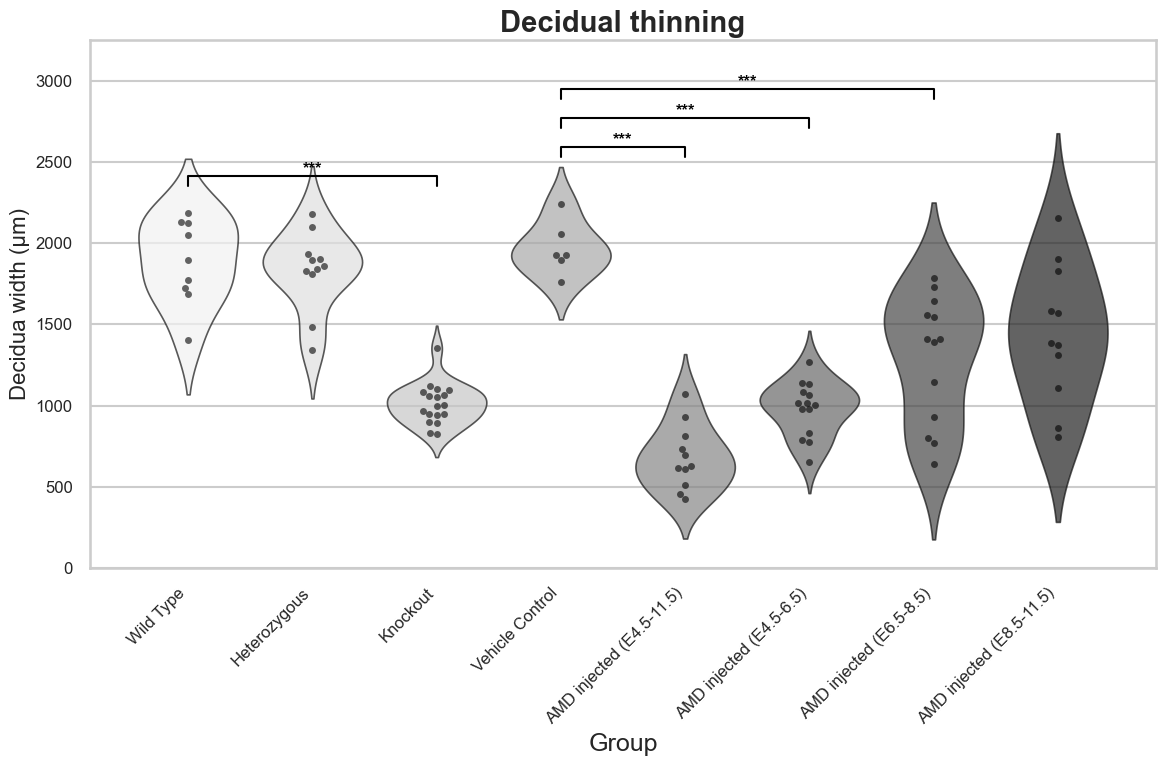

In [3]:
analyze_and_plot(
    row_name="decidua width", 
    plot_title="Decidual thinning", 
    y_axis_label="Decidua width (µm)", 
    save_filename="decidua_plot.pdf"
)

<h2>Figure 4B</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97877/4113467422.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='Value', data=plot_df, palette='Greys', inner=None, linewidth=1.2, alpha=0.7)


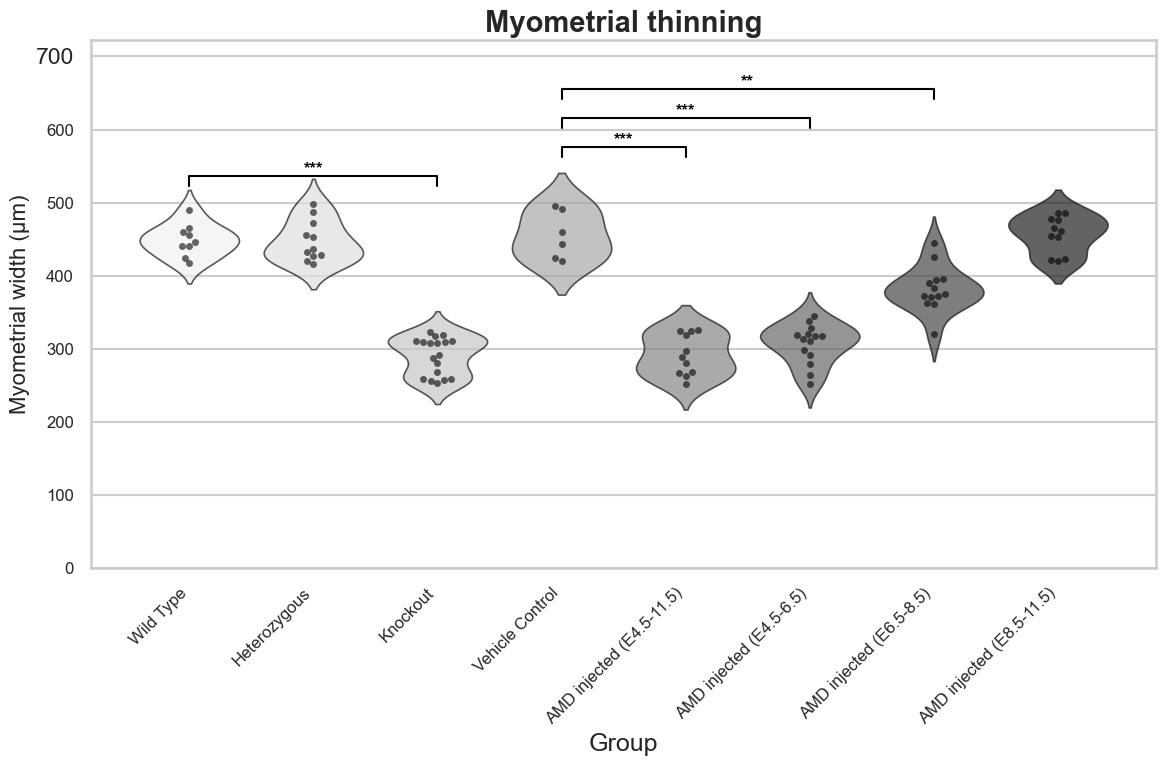

In [4]:
analyze_and_plot(
    row_name="myometrial width", 
    plot_title="Myometrial thinning", 
    y_axis_label="Myometrial width (µm)", 
    save_filename="myometrial_plot.pdf"
)

<h2>Extended Figure 4E</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_97877/4113467422.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='Value', data=plot_df, palette='Greys', inner=None, linewidth=1.2, alpha=0.7)


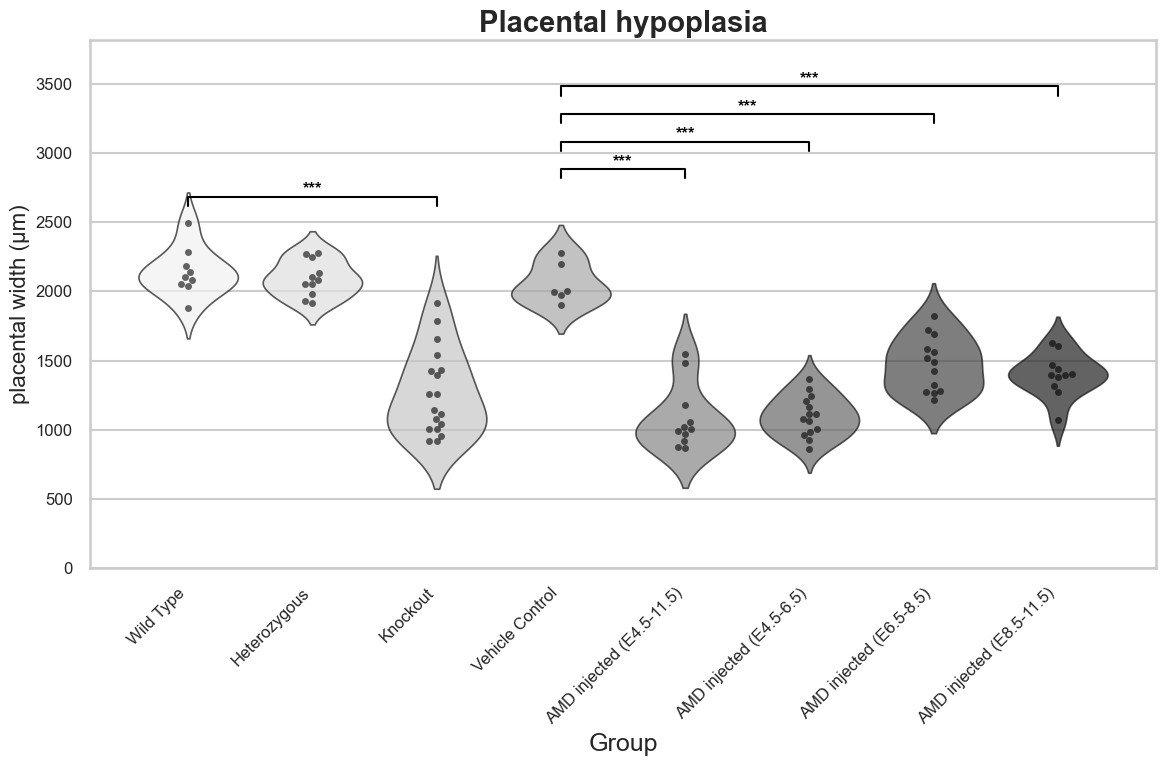

In [5]:
analyze_and_plot(
    row_name="placenta width", 
    plot_title="Placental hypoplasia", 
    y_axis_label= "placental width (µm)", 
    save_filename="placenta_plot.pdf"
)

<h2>Extended Figure 4F</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_42277/4113467422.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='Value', data=plot_df, palette='Greys', inner=None, linewidth=1.2, alpha=0.7)


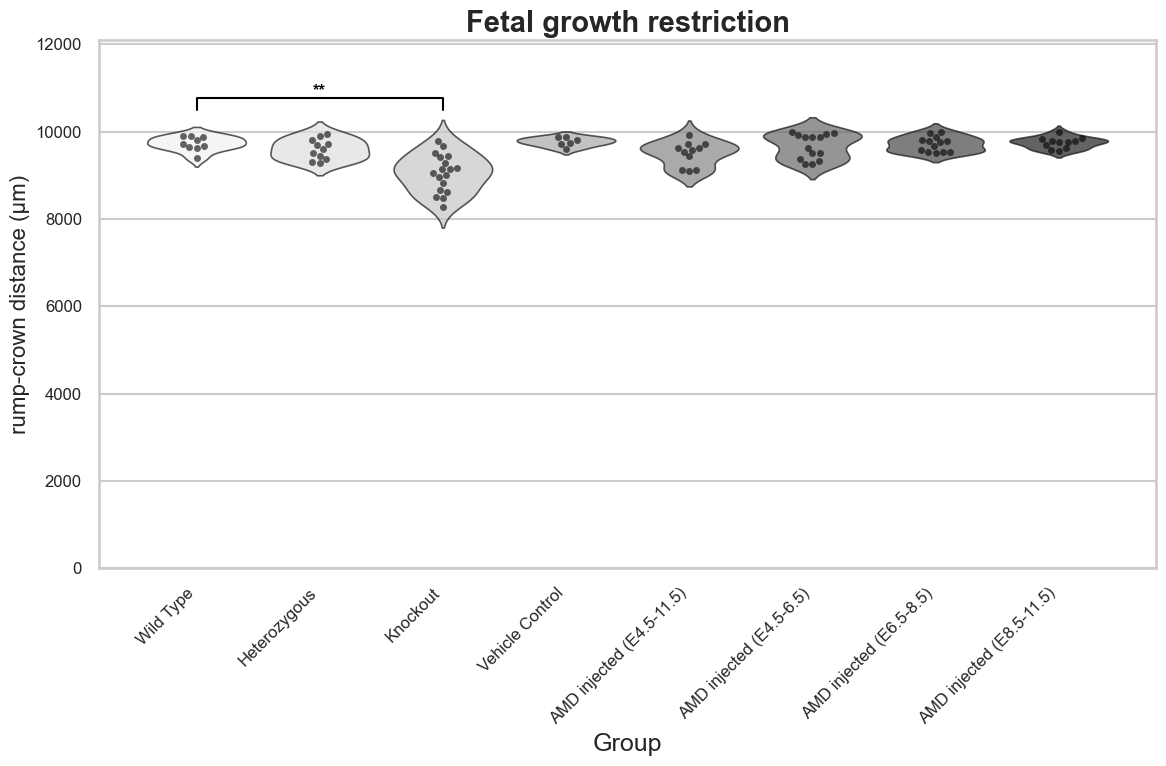

In [70]:
analyze_and_plot(
    row_name="rump-crown distance", 
    plot_title="Fetal growth restriction", 
    y_axis_label= "rump-crown distance (µm)", 
    save_filename="embryo_plot.pdf"
)